**REPORT-1 : Exploration , data visualization and data pre-processing Report**

**CO2 Emissions Prediction: Data Preprocessing**

Author : Nithin K 

**Introduction**
Climate change mitigation is a global priority, with transportation being a major source of CO₂ emissions. This project focuses on predicting vehicle emissions in France using 2013 homologation data from UTAC/ADEME, which includes features like fuel type, hybrid type, vehicle mass, gearbox, and fuel consumption. Various machine learning models ( XYZ - in progress.....tbd) are used to estimate emissions based on these characteristics. The predictions are then linked to France’s EEA database of total vehicles produced untill 2024 , to predict which of the models  tied to emission levels.

**Project Scope**
 
This notebook is part-1  of a ML  project 1 that aims to build a predictive model for CO2 emission of cars sold in France in 2013.

The dataset includes : 

- Fuel consumption,
- CO2 emissions,
- Air pollutant emissions (as per Euro standard,
- Vehicle technical characteristics (brand, model, engine type, etc,

The goal of this notebook is to:
- Download or load the dataset,
- Perform initial exploration,
- Visualize, Manipulate and generates loigcal Plots
- Clean and preprocess the data for modeling,
- Analyze factors influencing CO2 emissions (g/km) in vehicles.


**Dataset Overview**

Dataset used as follows: 

   **Title:**
   *[2013] Emissions de polluants, CO2 et caractéristiques des véhicules commercialisés en France*

   📍 Available on [data.gouv.fr](https://www.data.gouv.fr/fr/datasets/emissions-de-co2-et-de-polluants-des-vehicules-commercialises-en-france/) 
   
   📄 Accompanied by a variable dictionary: **Dictionnaire des variables**

**Dataset Briefing**

For each vehicle, the original data provided by UTAC includes:

   - Fuel consumption
   - Carbon dioxide (CO₂) emissions
   - Air pollutant emissions, regulated under the Euro standard
   - Complete technical specifications of the vehicle, such as:
      - Vehicle range
      - Brand and model
      - CNIT number (unique vehicle ID)
      - Type of energy/fuel used (e.g., diesel, petrol, electric)



**Context**

The data comes from the **vehicle approval services of automobile manufacturers**,


ADEME (the French Agency for Ecological Transition) acquires the data from the,
**Union Technique de l’Automobile, du Motocycle et du Cycle (UTAC)**,<br>
which is responsible for the approval of vehicles before they are released on the market.<br>
This process is carried out in collaboration with the **Ministry of Sustainable Development**,


**Dataset Update** : Initially the dataset contained 44850 entries with 26 colums.Upon close inspection,several duplicate rows were identified and removed to ensure good data quality.
After the deduplication process, the dataset was reduced to 7668 rows with 24 colums of unique entries.


In [143]:
# Import the necessary libraries

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
# Load the data : France 2013 data set of vehicles registered in June 2013  & the dictionary of the data set
# The data set is available at : https://www.data.gouv.fr/fr/datasets/immatriculations-de-vehicules-neufs-par-mois-et-par-departement/
# The dictionary of the data set is available at : https://www.data.gouv.fr/fr/datasets/immatriculations-de-vehicules-neufs-par-mois-et-par-departement/#_dictionary
# The data set is in csv format, with ';' as separator and 'latin1' encoding ( handles french special characters).

# Tip : pip install openpyxl to read excel files with pandas

cars_df = pd.read_csv('cl_JUIN_2013-complet3.csv',sep=';', encoding='latin1')
dict_df = pd.read_excel('carlab-annuaire-variable.xlsx')

display(cars_df.head(5))
display(dict_df.head(5))

,Marque,Modèle dossier,Modèle UTAC,Désignation commerciale,CNIT,Type Variante Version (TVV),Carburant,Hybride,Puissance administrative,Puissance maximale (kW),...,HC (g/km),NOX (g/km),HC+NOX (g/km),Particules (g/km),masse vide euro min (kg),masse vide euro max (kg),Champ V9,Date de mise à jour,Carrosserie,gamme
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147.0,...,0.052,0.032,NaN,0.002,1505,1505,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9,125.0,...,NaN,0.169,0.190,0.003,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100.0,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125.0,...,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER


,nom-colonne,typerubrique,longueur,légende,unité
0,lib_mrq_utac,varchar,12,la marque,NaN
1,lib_mod_doss,varchar,20,le modele du dossier,NaN
2,lib_mod,varchar,20,le modèle commercial,NaN
3,dscom,varchar,91,la désignation commerciale,NaN
4,cnit,varchar,15,le Code National d'Identification du Type (CNIT),NaN


**Features & Variables Identification --> English Meanings & initial grouping**

**Vehicle type data** 
| French Column                   | English Meaning  / Abbrevations                                                     |
| ------------------------------- | ----------------------------------------------------------------------------------- |
| **Marque**                      | Brand (manufacturer, e.g., Renault, Peugeot)                                        |
| **Modèle dossier**              | Model (internal record name)                                                        |
| **Modèle UTAC**                 | UTAC Model (official certification model – UTAC = French vehicle testing authority) |
| **Désignation commerciale**     | Commercial name (marketed model name)                                               |
| **CNIT**                        | National Type Identification Code (unique vehicle ID in France)                     |
| **Type Variante Version (TVV)** | Type / Variant / Version (specific configuration of the vehicle)                    |
| **Carburant**                   | Fuel type (Petrol, Diesel, Electric, etc.)                                          |
| **Carrosserie**                 | Body type (SUV, Sedan, Hatchback, etc.)                                             |
| **gamme**                       | Car Segment / Range / Series / Product line                                                       |

**Power & Engine data**

| French Column                   | English Meaning  / Abbrevations                                                     |
| ------------------------------- | ----------------------------------------------------------------------------------- |
| **Hybride**                     | Hybrid (Yes/No or type of hybrid)                                                   |
| **Puissance administrative**    | Fiscal power (tax horsepower, not actual engine power)                              |
| **Puissance maximale (kW)**     | Maximum power (in kilowatts)                                                        |
| **Boîte de vitesse**            | Gearbox type & nr of gears                                                          |

**Fuel consumption data**

| French Column                   | English Meaning  / Abbrevations                                                     |
| ------------------------------- | ----------------------------------------------------------------------------------- |
| **Consommation urbaine**        | Urban fuel consumption(l/100km)                                                     |
| **Consommation extra-urbaine**  | Extra-urban fuel consumption (l/100 km)                                             |
| **Consommation mixte**          | Combined (average) fuel consumptio(l/100)                                           |



**Emissions Related data**

| French                | English                               |
| --------------------- | ------------------------------------- |
| **CO2 (g/km)**        | CO₂ emissions (g/km)                  |
| **CO type I (g/km)**  | CO type I emissions (g/km)            |
| **HC (g/km)**         | Hydrocarbons emissions (grams per km) |
| **NOX (g/km)**        | Nitrogen Oxides emissions (g/km)      |
| **HC+NOX (g/km)**     | Combined Hydrocarbons + NOx           |
| **Particules (g/km)** | Particulate matter emissions          |


**Weight Related data**
| French                       | English                   |
| ---------------------------- | ------------------------- |
| **masse vide euro min (kg)** | Minimum curb weight (kg)  |
| **masse vide euro max (kg)** | Maximum curb weight (kg)  |



**Registration Related data**
| French                  | English                                                |
| ----------------------- | ------------------------------------------------------ |
| **Champ V9**            | Field denotes EURO emissions standard info             |
| **Date de mise à jour** | Last update date                                       |






**Data Exploration**

In [145]:
#------------------------------------------
# Displaying the data set information
#-----------------------------------------
cars_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44850 entries, 0 to 44849
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Marque                                44850 non-null  str    
 1   Modèle dossier                        44850 non-null  str    
 2   Modèle UTAC                           44850 non-null  str    
 3   Désignation commerciale               44850 non-null  str    
 4   CNIT                                  44850 non-null  str    
 5   Type Variante Version (TVV)           44850 non-null  str    
 6   Carburant                             44850 non-null  str    
 7   Hybride                               44850 non-null  str    
 8   Puissance administrative              44850 non-null  int64  
 9   Puissance maximale (kW)               44850 non-null  float64
 10  Boîte de vitesse                      44850 non-null  str    
 11  Consommation urbaine (l/10

In [146]:
# To check the size of the Dataset - number of rows and columns
cars_df.shape

(44850, 26)

In [147]:
# checking for missing values : since we saw that there are some columns with less than 100% non-null values, we will check for missing values in the data set.
# We will check for missing values in the data set and display the number of missing values in each column.
# We will use the isnull() function to check for missing values and sum() function to count the number of missing values in each column.
# We will display the number of missing values in each column using the display() function.

display(cars_df.isnull().sum())

Marque                                      0
Modèle dossier                              0
Modèle UTAC                                 0
Désignation commerciale                     0
CNIT                                        0
Type Variante Version (TVV)                 0
Carburant                                   0
Hybride                                     0
Puissance administrative                    0
Puissance maximale (kW)                     0
Boîte de vitesse                            0
Consommation urbaine (l/100km)             42
Consommation extra-urbaine (l/100km)       42
Consommation mixte (l/100km)               39
CO2 (g/km)                                 39
CO type I (g/km)                          303
HC (g/km)                               34447
NOX (g/km)                                303
HC+NOX (g/km)                           10659
Particules (g/km)                        3142
masse vide euro min (kg)                    0
masse vide euro max (kg)          

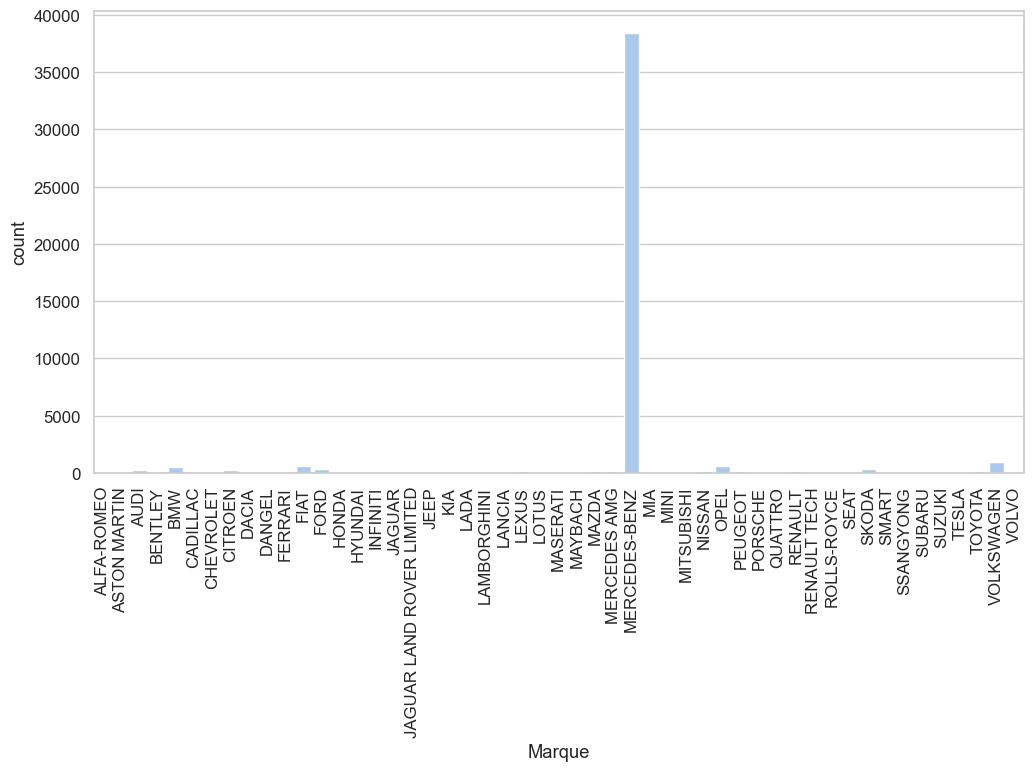

In [148]:
# Feature  checks & plots

# Plot the distribution of samples among car brands

plt.figure(figsize=(12,6))
sns.countplot(data=cars_df, x='Marque')
plt.xticks(rotation=90)
plt.show()      


We can see clearly observe that Brand / Marque : **MERCEDES-BENZ** seems to be overrepresented in the dataset. To better understand , <br>
lets zoom into **MERCEDES-BENZ** and explore the distrbution of its vehicles.<br>

Secondly, the next highest seems to be of **VOLKSWAGEN** , but data seems OK from this plot.

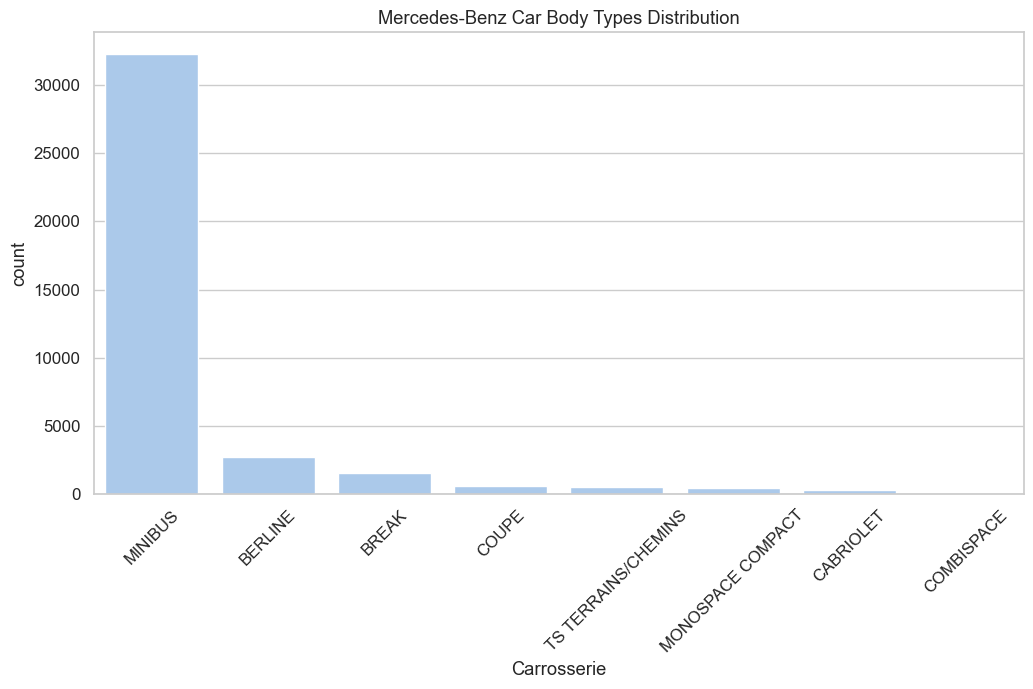

In [149]:
# Plot type or cars under mercedes-benz brand


mercedes_cars = cars_df[cars_df['Marque'] == 'MERCEDES-BENZ']

plt.figure(figsize=(12,6))
sns.countplot(data=mercedes_cars,x='Carrosserie',order=mercedes_cars['Carrosserie'].value_counts().index)

plt.xticks(rotation=45)
plt.title("Mercedes-Benz Car Body Types Distribution")
plt.show()
                    
                

In [150]:
# Display type and number of cars represented for MERCEDES-BENZ brand
print('Distribution within MMERCEDES-BENZ samples')
print(cars_df.Carrosserie[cars_df.Marque == 'MERCEDES-BENZ'].value_counts())
print('\n')

# display unique MERCEDES commercial model and CNIT codes
print('Nr of unique commercial model: {}'.format(cars_df['Désignation commerciale'][cars_df.Marque == 'MERCEDES-BENZ'].nunique()))
print('Nr of unique CNIT code: {}'.format(cars_df.CNIT[cars_df.Marque == 'MERCEDES-BENZ'].nunique()))
print('\n')

Distribution within MMERCEDES-BENZ samples
Carrosserie
MINIBUS                32244
BERLINE                 2749
BREAK                   1540
COUPE                    614
TS TERRAINS/CHEMINS      525
MONOSPACE COMPACT        434
CABRIOLET                332
COMBISPACE                12
Name: count, dtype: int64


Nr of unique commercial model: 292
Nr of unique CNIT code: 38270




In [151]:
# cars_df.duplicated(subset=['CNIT']).sum()

It appears that MERCEDES registered many different versions for what seem to be similar models. These versions likely share the same characteristics, resulting in duplicated rows within the dataset.

In [152]:
# Remove columns with identical or redundant information
# checking duplpicates based on unique identifier
# since there can be multiple cars wtih same CNNIT but wwith different CO2 values , which hold good for unique identifier.

cars_df.drop(labels=['CNIT', 'Type Variante Version (TVV)'], axis=1, inplace=True)

# Count the number of duplicated rows in the dataset
print('Number of duplicated rows:')
print(cars_df.duplicated().value_counts())


#This gives you only the rows marked True (excluding the first occurrence)
dup_rows = cars_df[cars_df.duplicated()]

# # #print them in tabular format   
print('Sample of duplicated rows in tabular format:')
print(dup_rows.head(5))

print('---------------------------------------------------------------------')

# This gives you all the duplicated rows (including the first occurrence)
dup_rows_all = cars_df[cars_df.duplicated(keep=False)]
print('Sample of all duplicated rows in tabular format:')
print(dup_rows_all.head(5))


Number of duplicated rows:
True     37182
False     7668
Name: count, dtype: int64
Sample of duplicated rows in tabular format:
        Marque Modèle dossier Modèle UTAC  Désignation commerciale Carburant  \
3   ALFA-ROMEO            159         159     159 2.0 JTDm (136ch)        GO   
5   ALFA-ROMEO            159         159     159 2.0 JTDm (170ch)        GO   
9   ALFA-ROMEO            159         159  159 SW 2.0 JTDm (136ch)        GO   
11  ALFA-ROMEO            159         159  159 SW 2.0 JTDm (170ch)        GO   
13  ALFA-ROMEO    AR8C SPIDER   8C SPIDER                8C SPIDER        ES   

   Hybride  Puissance administrative  Puissance maximale (kW)  \
3      non                         7                    100.0   
5      non                         9                    125.0   
9      non                         7                    100.0   
11     non                         9                    125.0   
13     non                        38                    331.0   



**To visually plot and check all duplicate groups (random)**

In [153]:
# To check if the duplicated rows are exact duplicates or if they differ in some columns, we can sort the duplicated rows by all columns and display the first few rows.
dup_rows_all.sort_values(by=list(cars_df.columns)).head(10)

,Marque,Modèle dossier,Modèle UTAC,Désignation commerciale,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),...,HC (g/km),NOX (g/km),HC+NOX (g/km),Particules (g/km),masse vide euro min (kg),masse vide euro max (kg),Champ V9,Date de mise à jour,Carrosserie,gamme
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),GO,non,7,100.0,M 6,6.6,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),GO,non,7,100.0,M 6,6.6,...,NaN,0.149,0.175,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),GO,non,9,125.0,M 6,6.9,...,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
5,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),GO,non,9,125.0,M 6,6.9,...,NaN,0.164,0.193,0.001,1565,1565,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
8,ALFA-ROMEO,159,159,159 SW 2.0 JTDm (136ch),GO,non,7,100.0,M 6,6.8,...,NaN,0.149,0.175,0.001,1615,1615,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
9,ALFA-ROMEO,159,159,159 SW 2.0 JTDm (136ch),GO,non,7,100.0,M 6,6.8,...,NaN,0.149,0.175,0.001,1615,1615,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
10,ALFA-ROMEO,159,159,159 SW 2.0 JTDm (170ch),GO,non,9,125.0,M 6,7.1,...,NaN,0.164,0.193,0.001,1615,1615,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
11,ALFA-ROMEO,159,159,159 SW 2.0 JTDm (170ch),GO,non,9,125.0,M 6,7.1,...,NaN,0.164,0.193,0.001,1615,1615,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
12,ALFA-ROMEO,AR8C SPIDER,8C SPIDER,8C SPIDER,ES,non,38,331.0,M 6,24.4,...,0.038,0.027,NaN,NaN,1750,1750,715/2007*692/2008EURO5,juin-13,CABRIOLET,LUXE
13,ALFA-ROMEO,AR8C SPIDER,8C SPIDER,8C SPIDER,ES,non,38,331.0,M 6,24.4,...,0.038,0.027,NaN,NaN,1750,1750,715/2007*692/2008EURO5,juin-13,CABRIOLET,LUXE


As expected, we find duplicated rows in the dataset. It appears that this issue is not unique to **MERCEDES-BENZ**, so let's proceed to remove all duplicate entries.

**Remove duplicates in the entire dataset (note : 2 colums are already dropped [CNIT & VPP])**

In [154]:
# Remove duplicate rows
cars_df.drop_duplicates(inplace=True)

# Check the new dataset 
print(cars_df.info())


<class 'pandas.DataFrame'>
Index: 7668 entries, 0 to 44849
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Marque                                7668 non-null   str    
 1   Modèle dossier                        7668 non-null   str    
 2   Modèle UTAC                           7668 non-null   str    
 3   Désignation commerciale               7668 non-null   str    
 4   Carburant                             7668 non-null   str    
 5   Hybride                               7668 non-null   str    
 6   Puissance administrative              7668 non-null   int64  
 7   Puissance maximale (kW)               7668 non-null   float64
 8   Boîte de vitesse                      7668 non-null   str    
 9   Consommation urbaine (l/100km)        7644 non-null   float64
 10  Consommation extra-urbaine (l/100km)  7644 non-null   float64
 11  Consommation mixte (l/100km)    

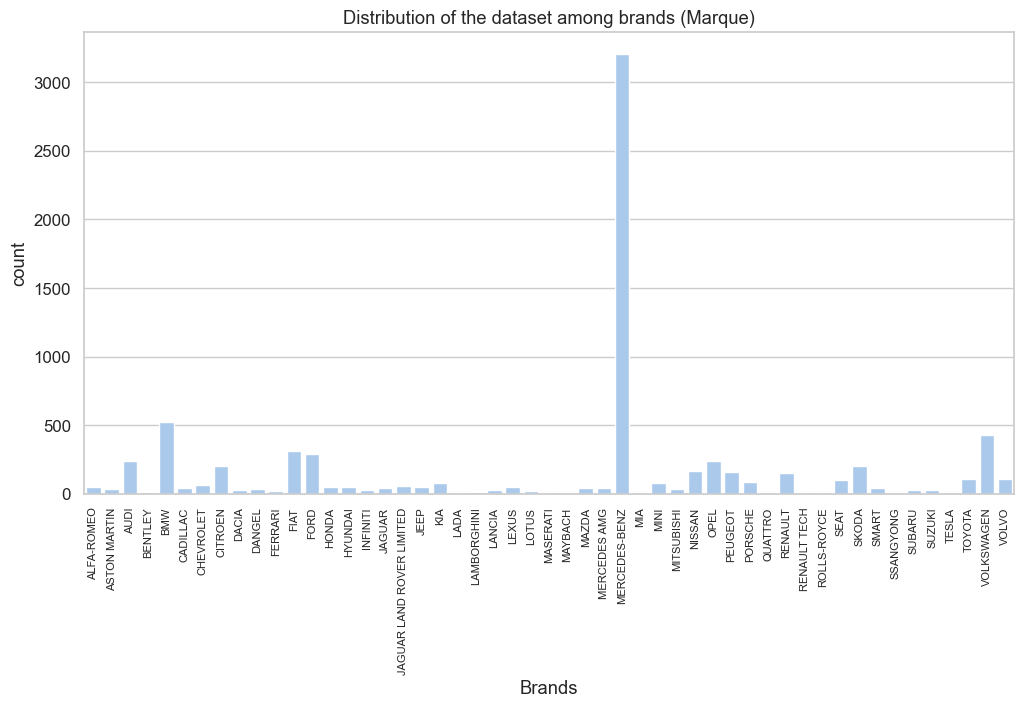

In [155]:
# Plot again the distribution of samples among brands
fig = plt.figure(figsize=(12,6))
sns.countplot(data=cars_df, x='Marque') 
plt.xticks(rotation=90, size=8)
plt.xlabel('Brands')
plt.title('Distribution of the dataset among brands (Marque)')
plt.show()

The datset now seems to have more balanced distribution across Brands(Marque), although ***MERCEDES-BENZ*** is still dominant.

 **REMOVAL of irrelavant data**

 Since analysis focuses on CO2 emissions , we can drop coloums related to effect/result of pollution rather than cause , and also date
 
  
  CO type I (g/km)                      <br>
  HC (g/km)                             <br>
  NOX (g/km)                            <br>
  HC+NOX (g/km)                         <br>
  Particules (g/km)                     <br>
  Date de mise à jour                       
   


In [156]:
# Remove or drop irrelevant colums

col_to_drop_1 = ['CO type I (g/km)', 'HC (g/km)', 'NOX (g/km)', 'HC+NOX (g/km)', 'Particules (g/km)', 'Date de mise à jour']

cars_df = cars_df.drop(columns=col_to_drop_1)

**REMOVAL of selected descriptive colums that do not directly impact CO2 emissions**

 Marque                             
 Modèle dossier                           
 Modèle UTAC                      
 Désignation commerciale                 
 Champ V9                             

In [157]:
# Removal of the columns that do not directly contribute to the analysis of CO2 emissions.

col_to_drop_2 = ['Marque', 'Modèle dossier', 'Modèle UTAC', 'Désignation commerciale', 'Champ V9']
cars_df = cars_df.drop(columns=col_to_drop_2)   

In [158]:
# Disply the new dataset after dropping the irrelevant columns
display(cars_df.head(5))

#display the size of the new dataset after dropping the irrelevant columns
print('Size of the new dataset after dropping irrelevant columns:',cars_df.shape)

#print new line for better readability
print('\n')
# information about the new dataset after dropping the irrelevant columns
print('Information about the new dataset after dropping irrelevant columns:')
print('\n')
cars_df.info()

,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),Consommation mixte (l/100km),CO2 (g/km),masse vide euro min (kg),masse vide euro max (kg),Carrosserie,gamme
0,ES,non,12,147.0,M 6,11.3,5.8,7.8,182.0,1505,1505,BREAK,MOY-SUPER
1,GO,non,9,125.0,M 6,6.6,4.3,5.1,136.0,1565,1565,BERLINE,MOY-SUPER
2,GO,non,7,100.0,M 6,6.6,4.2,5.1,134.0,1565,1565,BERLINE,MOY-SUPER
4,GO,non,9,125.0,M 6,6.9,4.3,5.3,139.0,1565,1565,BERLINE,MOY-SUPER
6,ES,non,12,147.0,M 6,11.5,6.0,8.0,186.0,1555,1555,BREAK,MOY-SUPER


Size of the new dataset after dropping irrelevant columns: (7668, 13)


Information about the new dataset after dropping irrelevant columns:


<class 'pandas.DataFrame'>
Index: 7668 entries, 0 to 44849
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Carburant                             7668 non-null   str    
 1   Hybride                               7668 non-null   str    
 2   Puissance administrative              7668 non-null   int64  
 3   Puissance maximale (kW)               7668 non-null   float64
 4   Boîte de vitesse                      7668 non-null   str    
 5   Consommation urbaine (l/100km)        7644 non-null   float64
 6   Consommation extra-urbaine (l/100km)  7644 non-null   float64
 7   Consommation mixte (l/100km)          7647 non-null   float64
 8   CO2 (g/km)                            7647 non-null   float64
 9   masse vide euro min (kg

**Missing Values Check**

From the above info data we see that some rows are missing data. 

Firstly , the missing data has to be counted to know the proportion w.r.t the available data before removal.

In [159]:
# Count how many rows have at least one missing value (before removal)

missing_row_count = cars_df.isnull().any(axis=1).sum()
print(f'Number of rows with missing values before removal: {missing_row_count}')

Number of rows with missing values before removal: 24


There are 24 rows in the dataset with missing values.
Since this is relatively small in comparison to the overall dataset 7668 rows , we shall remove 24 rows to ensure data readiness for analysis.

In [160]:
# Remove rows with missing values
cars_df.dropna(inplace=True)

# Check the resulting dataframe
display(cars_df.head(2))
print(cars_df.info())

,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),Consommation mixte (l/100km),CO2 (g/km),masse vide euro min (kg),masse vide euro max (kg),Carrosserie,gamme
0,ES,non,12,147.0,M 6,11.3,5.8,7.8,182.0,1505,1505,BREAK,MOY-SUPER
1,GO,non,9,125.0,M 6,6.6,4.3,5.1,136.0,1565,1565,BERLINE,MOY-SUPER


<class 'pandas.DataFrame'>
Index: 7644 entries, 0 to 44849
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Carburant                             7644 non-null   str    
 1   Hybride                               7644 non-null   str    
 2   Puissance administrative              7644 non-null   int64  
 3   Puissance maximale (kW)               7644 non-null   float64
 4   Boîte de vitesse                      7644 non-null   str    
 5   Consommation urbaine (l/100km)        7644 non-null   float64
 6   Consommation extra-urbaine (l/100km)  7644 non-null   float64
 7   Consommation mixte (l/100km)          7644 non-null   float64
 8   CO2 (g/km)                            7644 non-null   float64
 9   masse vide euro min (kg)              7644 non-null   int64  
 10  masse vide euro max (kg)              7644 non-null   int64  
 11  Carrosserie                     

**Explore Quantitative Features**

count    7644.000000
mean      174.174123
std        50.885395
min        48.000000
25%       136.000000
50%       164.000000
75%       209.000000
max       572.000000
Name: CO2 (g/km), dtype: float64

Car(s) with the lowest CO2 emissions:


,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),Consommation mixte (l/100km),CO2 (g/km),masse vide euro min (kg),masse vide euro max (kg),Carrosserie,gamme
44820,GL,oui,10,158.0,A 6,0.0,5.5,1.8,48.0,1954,1954,BREAK,SUPERIEURE



Car(s) with the highest CO2 emissions:


,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),Consommation mixte (l/100km),CO2 (g/km),masse vide euro min (kg),masse vide euro max (kg),Carrosserie,gamme
116,ES,non,81,559.3,A 6,41.1,14.9,24.5,572.0,1815,1815,COUPE,LUXE


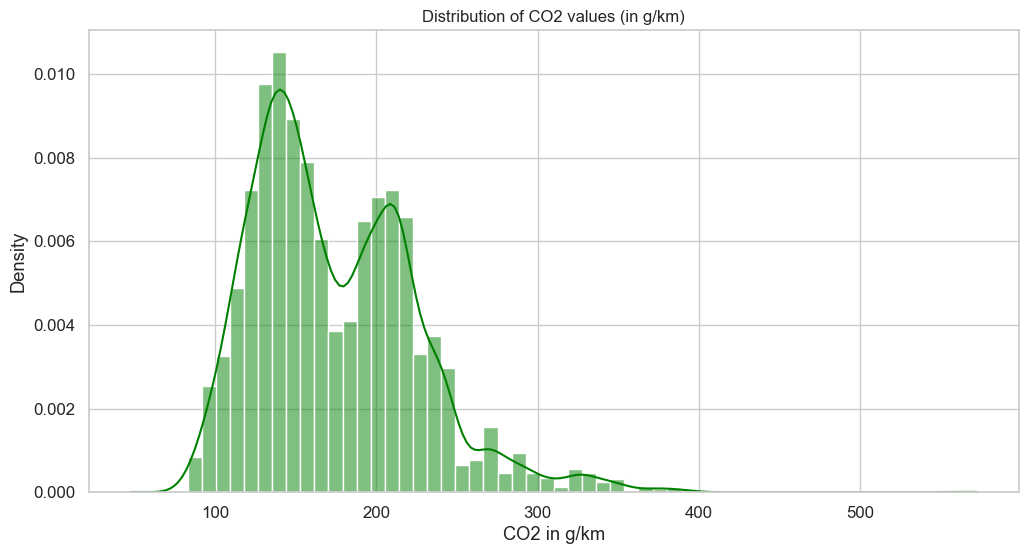

In [161]:
# Let's start by exploring the target variable 'co2'

# Plot the distribution of CO2 emissions
plt.figure(figsize=(12, 6))
sns.histplot(data=cars_df, x='CO2 (g/km)', bins=60, kde=True, color='green', stat='density', label='CO2')
plt.xlabel('CO2 in g/km')
plt.title('Distribution of CO2 values (in g/km)', size=12);


# Display descriptive statistics for CO2 emissions
print(cars_df['CO2 (g/km)'].describe())

# Display car) with the lowest CO2 emissions in the dataset
print('\nCar(s) with the lowest CO2 emissions:')
display(cars_df[cars_df['CO2 (g/km)'] == cars_df['CO2 (g/km)'].min()])

# Display car with the highest CO2 emissions in the dataset
print('\nCar(s) with the highest CO2 emissions:')   
display(cars_df[cars_df['CO2 (g/km)'] == cars_df['CO2 (g/km)'].max()])
print('\n')

This distribution is clearly bimodal, indicating two main groups of vehicles—one with CO₂ emissions centered around CO2 of 150g/km and another around 215g/km.

By plotting the Min & Max CO2 emissions , at the Max values we notice that there are also a few outliers with much higher emissions. 

Next, we shall  explore the distribution of other features and how they correlate with CO₂. 

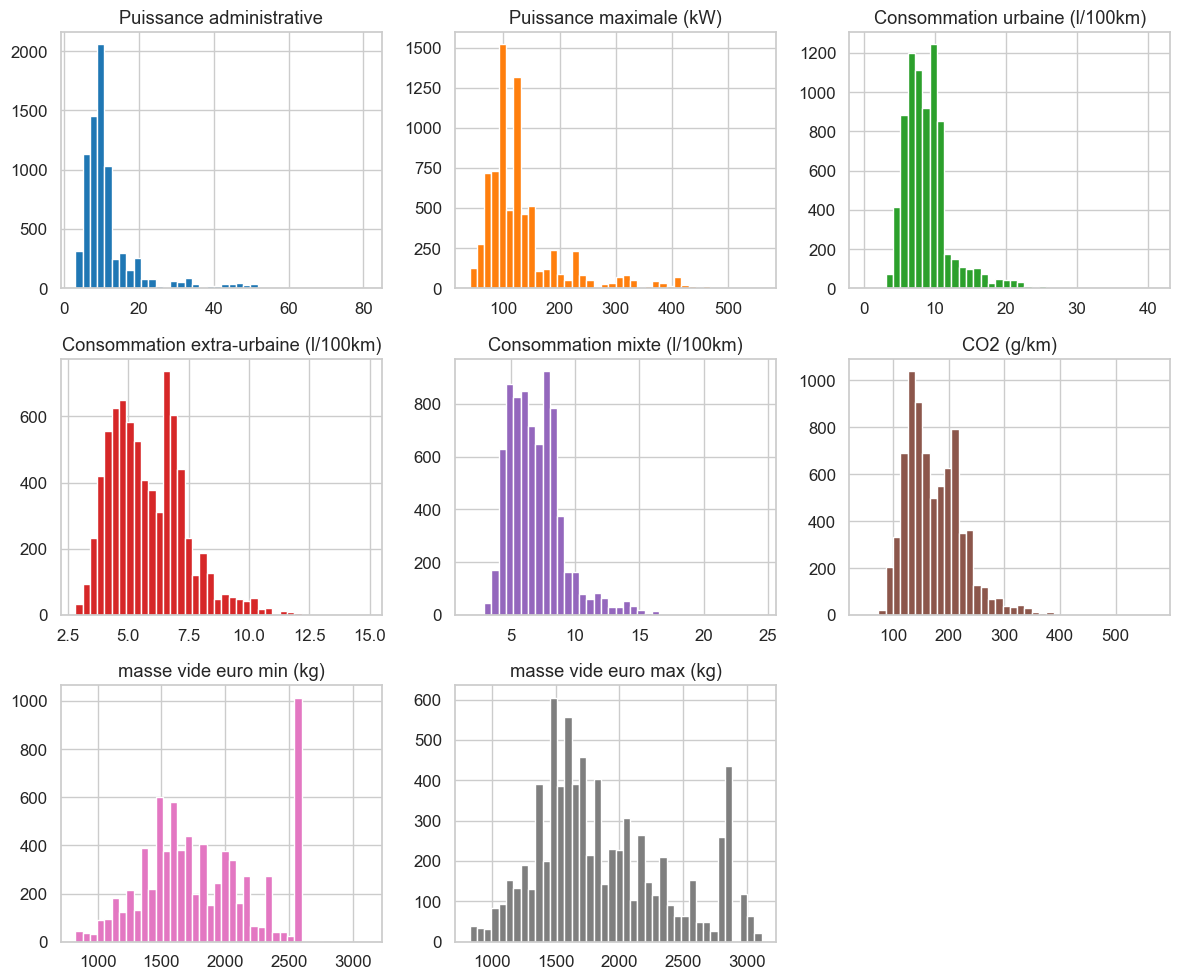

In [162]:
# Plot the distribution of CO2 emissions
axes = cars_df.hist(figsize=(12,10), bins=40)

colors = plt.cm.tab10.colors  # palette with multiple colors

for ax, color in zip(axes.flatten(), colors):
    for patch in ax.patches:
        patch.set_facecolor(color)

plt.tight_layout()
plt.show()

Most vehicles are moderatel powered ( not too high and not vey low as well)

Most vehicles have average to good efficiency. ( looking at the Consumption urban, non urban and mixed histogram )

Most vehicles are mid sized w.r.t weight is concerned.


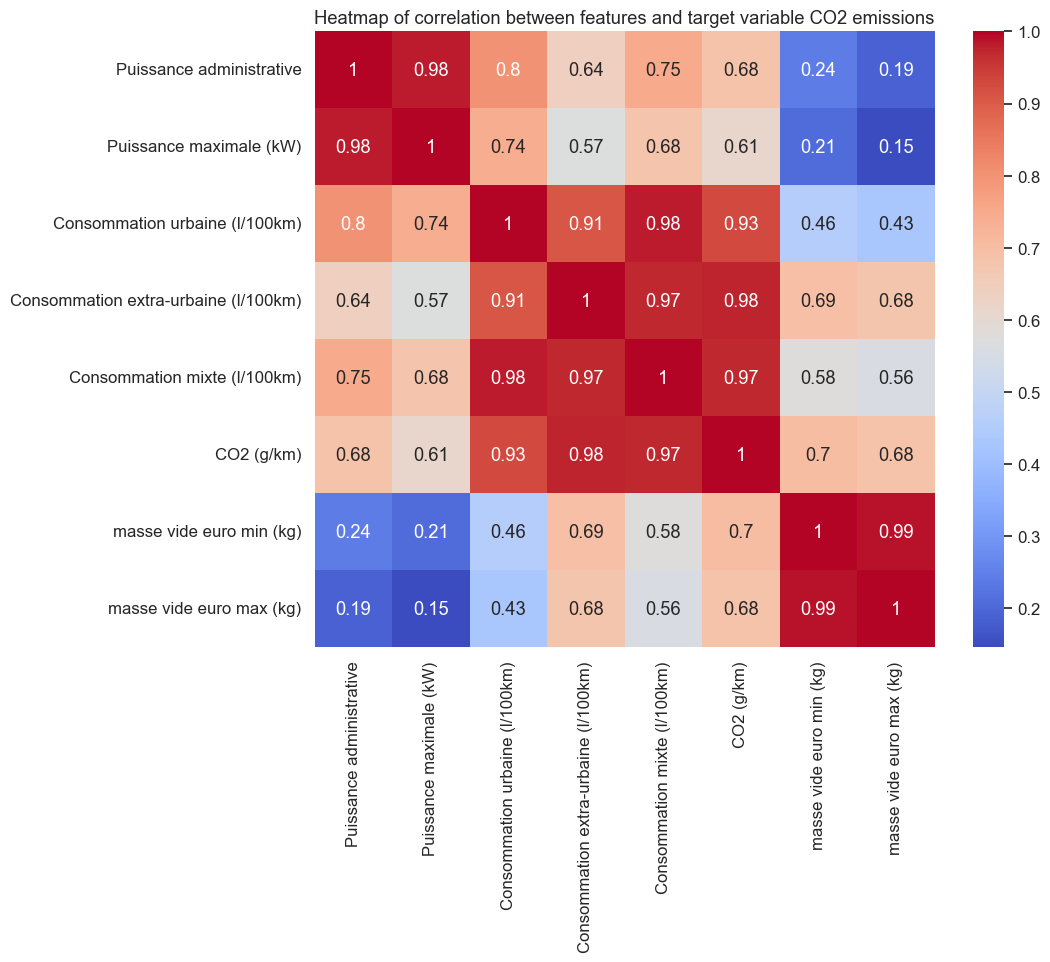

In [163]:
# Heatmap of correlation between features and target variable CO2 emissions

# Select only numeric columns for correlation
numeric_df = cars_df.select_dtypes(include=['int64', 'float64'])    

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()      
                    
# Plot the correlation map

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')        
plt.title('Heatmap of correlation between features and target variable CO2 emissions')
plt.show()
   

Observations based on the target variable **CO2** :
  - CO2 shows a strong correlation with all other features , which is a good indication to build a predictive model.

Additonally, some features are highly correlated with one another.For example :
  - 'masse vide euro min(kg)' and 'masse vide euro max (kg)'  have a correlation of 0.99 ( is expected due to the data relationship & definition)
  - 'Puissance administrative' and 'Puissance maximale (kW)'  have a correlation of 0.98 ( is expected due to the data relationship & definition)
  - 'Consommation mixte' is correlated with both 'Consommation urbaine'(0.98)  and   'Consommation extra-urbaine'(0.97)


Given this redundancy, we can consider removing , or keeping one of them by averaging across similar features  to improve readability and avoid multicollinearity.

In [164]:
cars_df.info()

<class 'pandas.DataFrame'>
Index: 7644 entries, 0 to 44849
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Carburant                             7644 non-null   str    
 1   Hybride                               7644 non-null   str    
 2   Puissance administrative              7644 non-null   int64  
 3   Puissance maximale (kW)               7644 non-null   float64
 4   Boîte de vitesse                      7644 non-null   str    
 5   Consommation urbaine (l/100km)        7644 non-null   float64
 6   Consommation extra-urbaine (l/100km)  7644 non-null   float64
 7   Consommation mixte (l/100km)          7644 non-null   float64
 8   CO2 (g/km)                            7644 non-null   float64
 9   masse vide euro min (kg)              7644 non-null   int64  
 10  masse vide euro max (kg)              7644 non-null   int64  
 11  Carrosserie                     

In [165]:
cars_df['mass_diff'] = cars_df['masse vide euro max (kg)'] - cars_df['masse vide euro min (kg)'] 
#print describe for mass_diff
print(cars_df['mass_diff'].describe())


count    7644.000000
mean       60.986002
std       105.112646
min         0.000000
25%         0.000000
50%         0.000000
75%        94.000000
max       763.000000
Name: mass_diff, dtype: float64


The dataset provides both min & max weight of each vehcle. But , we can clearly see here that :
   - 50% of the vehicles have no difference between the two.
   - Mean is 61kg between min & max variations
   - std is 105 considerable variation. Means some have 0 variation and some have apporx. 105 kg variation
   - min is 0 , no difference at all.
   - 25% & 50% of cars have ZERO weight difference.
   - 75% vary with 94kg( top 25% only have this variation)
   - Max is 763 kg thats HUGE difference

   Its highly skewed.Hence to avoid multicollinearity and to have a meaningful weight feature , we can use the average of these features and drop the min & max masse.

In [166]:
# Create average curb weight column
cars_df['masse_vide_avg'] = cars_df[['masse vide euro min (kg)', 'masse vide euro max (kg)']].mean(axis=1)

# Drop the original min and max curb weight columns & the mass_diff column since it is not relevant for the analysis
cars_df = cars_df.drop(columns=['masse vide euro min (kg)', 'masse vide euro max (kg)', 'mass_diff'])


# Print the updated dataframe
cars_df.head(5)


,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),Consommation mixte (l/100km),CO2 (g/km),Carrosserie,gamme,masse_vide_avg
0,ES,non,12,147.0,M 6,11.3,5.8,7.8,182.0,BREAK,MOY-SUPER,1505.0
1,GO,non,9,125.0,M 6,6.6,4.3,5.1,136.0,BERLINE,MOY-SUPER,1565.0
2,GO,non,7,100.0,M 6,6.6,4.2,5.1,134.0,BERLINE,MOY-SUPER,1565.0
4,GO,non,9,125.0,M 6,6.9,4.3,5.3,139.0,BERLINE,MOY-SUPER,1565.0
6,ES,non,12,147.0,M 6,11.5,6.0,8.0,186.0,BREAK,MOY-SUPER,1555.0


In [167]:
# Remove columns with high correlation between other features
# We can think of also removing Puissance maximale  , since it has low correlation in compaarison to Puissance administrative

col_high_corr_to_remove = ['Consommation mixte (l/100km)']
cars_df.drop(labels=col_high_corr_to_remove, axis=1, inplace=True)

cars_df.head(5)

,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),CO2 (g/km),Carrosserie,gamme,masse_vide_avg
0,ES,non,12,147.0,M 6,11.3,5.8,182.0,BREAK,MOY-SUPER,1505.0
1,GO,non,9,125.0,M 6,6.6,4.3,136.0,BERLINE,MOY-SUPER,1565.0
2,GO,non,7,100.0,M 6,6.6,4.2,134.0,BERLINE,MOY-SUPER,1565.0
4,GO,non,9,125.0,M 6,6.9,4.3,139.0,BERLINE,MOY-SUPER,1565.0
6,ES,non,12,147.0,M 6,11.5,6.0,186.0,BREAK,MOY-SUPER,1555.0


**REPLOT THE HEATMAP** to check and verfiy the correlations with optimized variables.

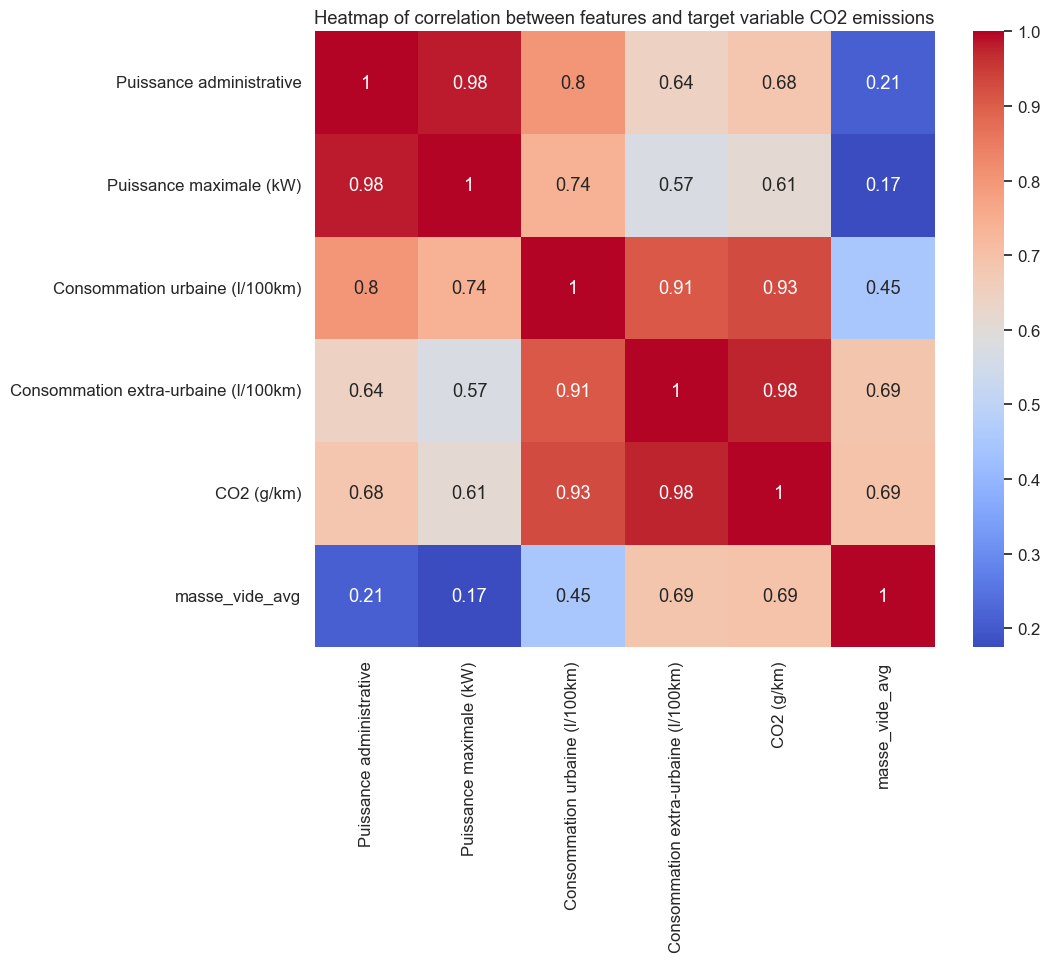

In [168]:
# Replot Heatmap of correlation between features and target variable CO2 emissions

# Select only numeric columns for correlation
numeric_df = cars_df.select_dtypes(include=['int64', 'float64'])    

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()      
                    
# Plot the correlation map

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')        
plt.title('Heatmap of correlation between features and target variable CO2 emissions')
plt.show()

In [169]:
# info of the final dataset after all the preprocessing steps
cars_df.info()

<class 'pandas.DataFrame'>
Index: 7644 entries, 0 to 44849
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Carburant                             7644 non-null   str    
 1   Hybride                               7644 non-null   str    
 2   Puissance administrative              7644 non-null   int64  
 3   Puissance maximale (kW)               7644 non-null   float64
 4   Boîte de vitesse                      7644 non-null   str    
 5   Consommation urbaine (l/100km)        7644 non-null   float64
 6   Consommation extra-urbaine (l/100km)  7644 non-null   float64
 7   CO2 (g/km)                            7644 non-null   float64
 8   Carrosserie                           7644 non-null   str    
 9   gamme                                 7644 non-null   str    
 10  masse_vide_avg                        7644 non-null   float64
dtypes: float64(5), int64(1), str(5)


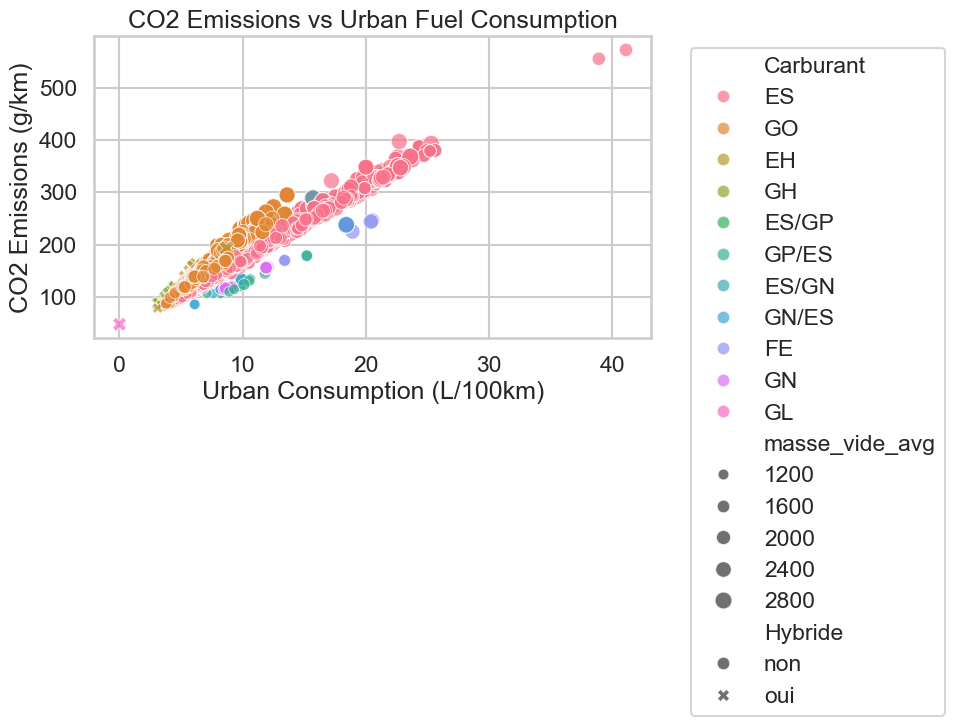

In [170]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cars_df,
    x='Consommation urbaine (l/100km)',
    y='CO2 (g/km)',
    hue='Carburant',        # color by fuel type
    style='Hybride',        # marker style
    size='masse_vide_avg',  # bubble size = weight
    alpha=0.7
)

plt.title("CO2 Emissions vs Urban Fuel Consumption")
plt.xlabel("Urban Consumption (L/100km)")
plt.ylabel("CO2 Emissions (g/km)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Hybrid oui : less consumption

Heavier vehicles more consumption & more CO2 emissions

ES : Petrol variants have higher emissions

GO: Diesel variants are showing lower emissions in comparison to petrol variants.

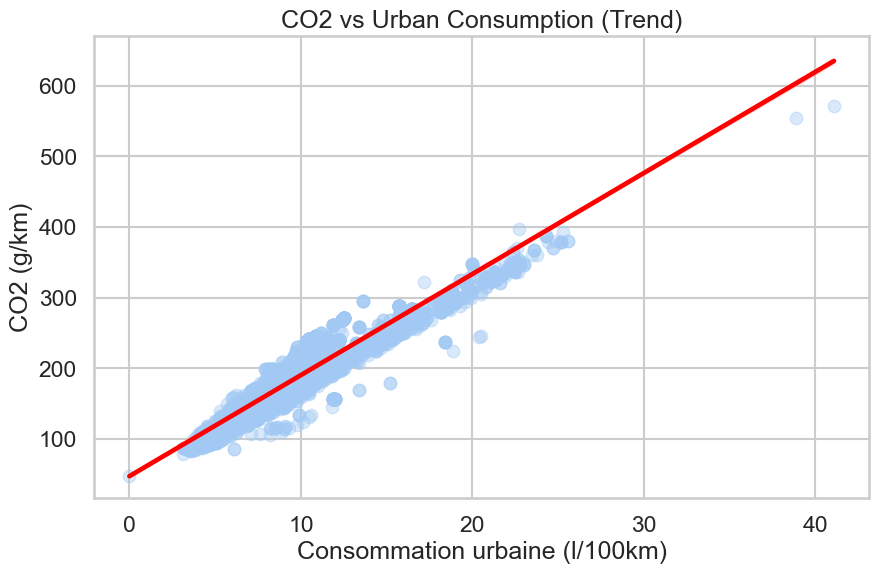

In [171]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=cars_df,
    x='Consommation urbaine (l/100km)',
    y='CO2 (g/km)',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("CO2 vs Urban Consumption (Trend)")
plt.show()

CO2 emissions increases with fuel consumption

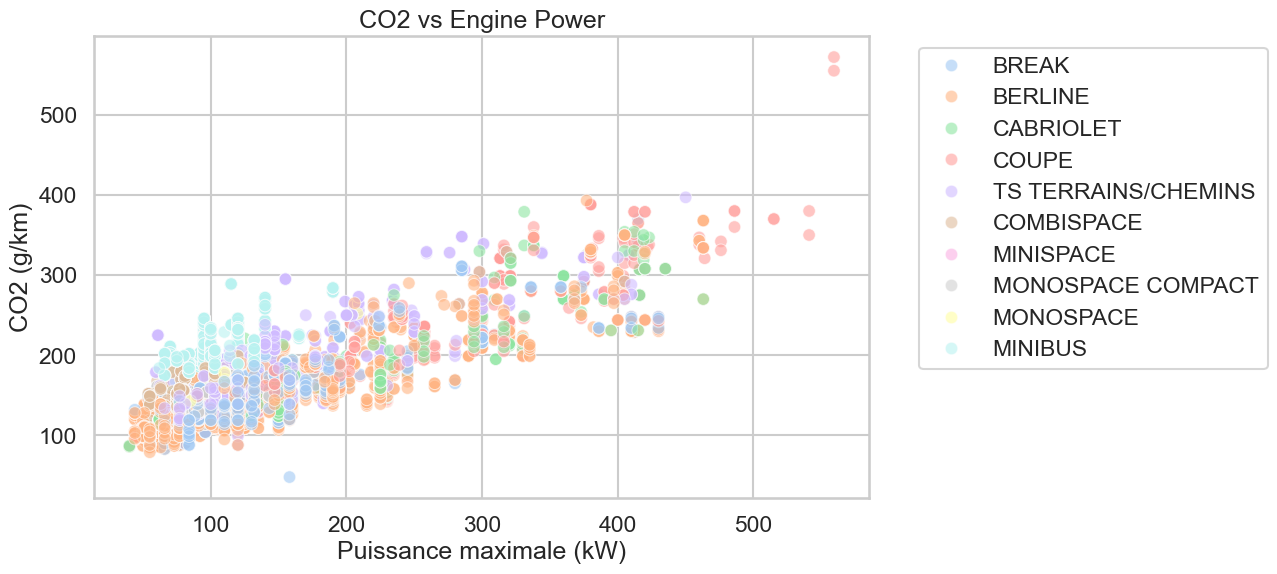

In [172]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cars_df,
    x='Puissance maximale (kW)',
    y='CO2 (g/km)',
    hue='Carrosserie',
    alpha=0.6
)

plt.title("CO2 vs Engine Power")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

More Power More Emissions

Different Vehicle types ( Carrosserie ) behave differently. It is spread across. 

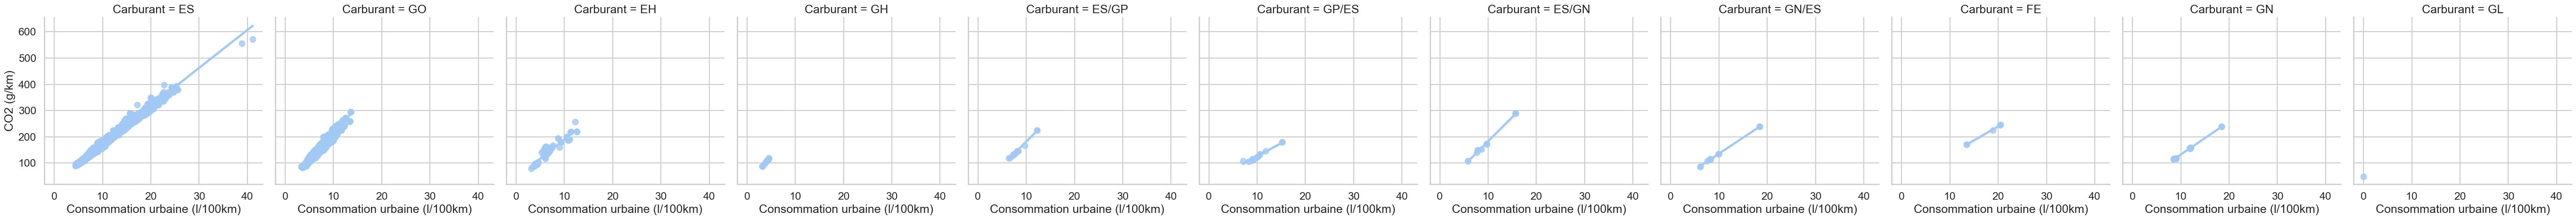

In [173]:
sns.lmplot(
    data=cars_df,
    x='Consommation urbaine (l/100km)',
    y='CO2 (g/km)',
    col='Carburant',
    height=5,
    aspect=1
);

<StringArray>
['ES', 'GO', 'EH', 'GH', 'ES/GP', 'GP/ES', 'ES/GN', 'GN/ES', 'FE', 'GN', 'GL']
Length: 11, dtype: str


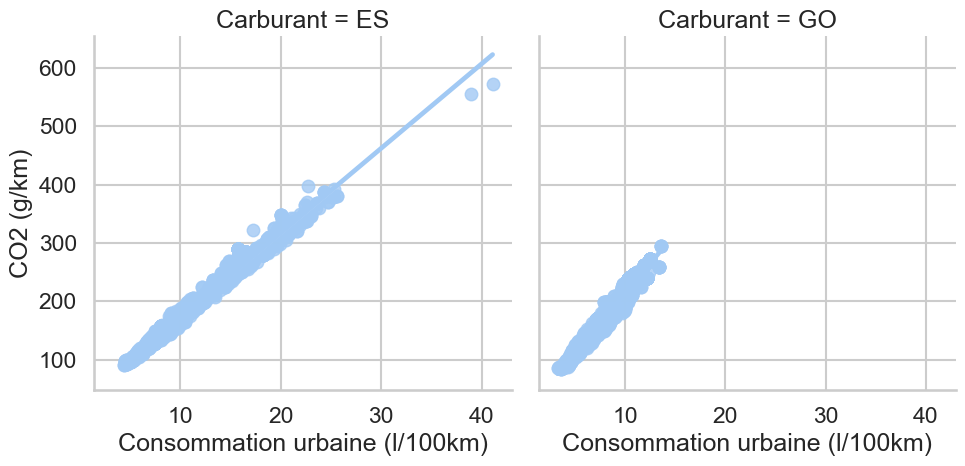

In [174]:
print(cars_df['Carburant'].unique())

fuel_types =['ES', 'GO']

filtered_cars_df = cars_df[cars_df['Carburant'].isin(fuel_types)]


sns.lmplot(
    data=filtered_cars_df,
    x='Consommation urbaine (l/100km)',
    y='CO2 (g/km)',
    col='Carburant',
    col_order=fuel_types,   # ensures correct order
    height=5,
    aspect=1
);


**KEY FINDINGS**

1. Fuel Consumption drives CO2:<br>
Strong positive relationship observed
Higher consumption → higher emissions

2. Vehicle Weight Matters:<br>
Heavier vehicles tend to emit more CO2<br>
Weight amplifies fuel consumption effects
3. Engine Power Influence:<br>
High-power vehicles show increased emissions<br>
Performance comes at an environmental cost
4. Outliers (High Emitters):<br>
Identified using IQR method
Likely:
large SUVs
high-performance vehicles
These represent extreme emission cases
5. Fuel Type Differences:<br>
Hybrid vehicles generally show lower emissions<br>
Conventional fuels dominate high CO2 range<br>

**CONCLUSION**

CO2 emissions are primarily driven by fuel consumption, with weight and engine power acting as amplifying factors.
A small subset of vehicles contributes disproportionately to emissions.

**Categorical Feature Analysis**       

**OR**    

**Qualitative Feature Analysis**

In [175]:
#display info of the final dataset after all the preprocessing steps
cars_df.info()

<class 'pandas.DataFrame'>
Index: 7644 entries, 0 to 44849
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Carburant                             7644 non-null   str    
 1   Hybride                               7644 non-null   str    
 2   Puissance administrative              7644 non-null   int64  
 3   Puissance maximale (kW)               7644 non-null   float64
 4   Boîte de vitesse                      7644 non-null   str    
 5   Consommation urbaine (l/100km)        7644 non-null   float64
 6   Consommation extra-urbaine (l/100km)  7644 non-null   float64
 7   CO2 (g/km)                            7644 non-null   float64
 8   Carrosserie                           7644 non-null   str    
 9   gamme                                 7644 non-null   str    
 10  masse_vide_avg                        7644 non-null   float64
dtypes: float64(5), int64(1), str(5)


In [176]:
# display the dataset after all the preprocessing steps
display(cars_df.head(5))

,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),CO2 (g/km),Carrosserie,gamme,masse_vide_avg
0,ES,non,12,147.0,M 6,11.3,5.8,182.0,BREAK,MOY-SUPER,1505.0
1,GO,non,9,125.0,M 6,6.6,4.3,136.0,BERLINE,MOY-SUPER,1565.0
2,GO,non,7,100.0,M 6,6.6,4.2,134.0,BERLINE,MOY-SUPER,1565.0
4,GO,non,9,125.0,M 6,6.9,4.3,139.0,BERLINE,MOY-SUPER,1565.0
6,ES,non,12,147.0,M 6,11.5,6.0,186.0,BREAK,MOY-SUPER,1555.0


Splitting Boite de vitesse : into two colums as Gearbox type and Gear number


In [177]:
# Split 'Boîte de vitesse' into two columns: 'gearbox_type' and 'num_gears'
cars_df[['gearbox_type', 'num_gears']] = cars_df['Boîte de vitesse'].str.split(' ', expand=True)

# Convert number of gears to integer (some may need handling if missing)
cars_df['num_gears'] = pd.to_numeric(cars_df['num_gears'], errors='coerce')  # NaN if missing

In [178]:
display(cars_df.head(5))

,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),CO2 (g/km),Carrosserie,gamme,masse_vide_avg,gearbox_type,num_gears
0,ES,non,12,147.0,M 6,11.3,5.8,182.0,BREAK,MOY-SUPER,1505.0,M,6
1,GO,non,9,125.0,M 6,6.6,4.3,136.0,BERLINE,MOY-SUPER,1565.0,M,6
2,GO,non,7,100.0,M 6,6.6,4.2,134.0,BERLINE,MOY-SUPER,1565.0,M,6
4,GO,non,9,125.0,M 6,6.9,4.3,139.0,BERLINE,MOY-SUPER,1565.0,M,6
6,ES,non,12,147.0,M 6,11.5,6.0,186.0,BREAK,MOY-SUPER,1555.0,M,6


**Unique Value Checks**

In [179]:
for col in cars_df.columns:
    unique_vals = cars_df[col].unique()
    print(f"\n🟦 {col} ({len(unique_vals)} unique values):\n{unique_vals}")


🟦 Carburant (11 unique values):
<StringArray>
['ES', 'GO', 'EH', 'GH', 'ES/GP', 'GP/ES', 'ES/GN', 'GN/ES', 'FE', 'GN', 'GL']
Length: 11, dtype: str

🟦 Hybride (2 unique values):
<StringArray>
['non', 'oui']
Length: 2, dtype: str

🟦 Puissance administrative (61 unique values):
[12  9  7 38 14  5  8  6  4 44 80 81 49 51 34 35 45 33 10 16 19 15 23 11
 18 22 17 31 20 47 21 24 41 42 13 48 25 57 26 46 32 27 50 43 60  3 40 72
 73 63 62 30 29 39 68 28 37 58 36 56 52]

🟦 Puissance maximale (kW) (220 unique values):
[147.  125.  100.  331.  120.   88.  172.5  77.   85.  103.   99.   70.
  62.   57.   51.   62.5  72.  381.  559.3 410.  422.  313.2 320.7 380.
 136.   90.   66.   63.  105.  188.   92.  118.  132.  221.  110.  180.
 130.  245.  150.  200.  155.  309.  230.  228.  412.  220.  258.  184.
 368.  213.  382.  165.  250.  316.  404.  386.  265.  460.  423.  373.
 377.   75.  160.  135.  190.  225.  235.  210.  300.  280.  330.  240.
 400.  408.  115.  203.  237.  415.  301.  248.  234.  

We clearly see that 'MOY-INFER' and 'MOY-INF'  are both same. Hence we can merge them

Tip_Note : Replace function has to be carefully used, else it will keep replacing the string in a unending loop, with number times it is execueted. 
Hence combine all the searches and repalce it once.

In [180]:
# # Merge MOY-INFER and MOY-INFERIEURE 
# cars_df['gamme'] = cars_df['gamme'].str.replace('MOY-INFERIEURE', 'MOY-INFER')
# print(cars_df['gamme'].unique())

In [181]:
# cars_df['gamme'] = cars_df['gamme'].str.replace('MOY-INF', 'MOY-INFER')
# print(cars_df['gamme'].unique())

In [182]:
cars_df['gamme'] = cars_df['gamme'].replace(
    ['MOY-INFERERERERER', 'MOY-INFERERERER','MOY-INF'],
    'MOY-INFER'
)


In [183]:
print(cars_df['gamme'].unique())

<StringArray>
['MOY-SUPER', 'LUXE', 'MOY-INFER', 'INFERIEURE', 'SUPERIEURE', 'ECONOMIQUE']
Length: 6, dtype: str


In [184]:
cars_df.info()

<class 'pandas.DataFrame'>
Index: 7644 entries, 0 to 44849
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Carburant                             7644 non-null   str    
 1   Hybride                               7644 non-null   str    
 2   Puissance administrative              7644 non-null   int64  
 3   Puissance maximale (kW)               7644 non-null   float64
 4   Boîte de vitesse                      7644 non-null   str    
 5   Consommation urbaine (l/100km)        7644 non-null   float64
 6   Consommation extra-urbaine (l/100km)  7644 non-null   float64
 7   CO2 (g/km)                            7644 non-null   float64
 8   Carrosserie                           7644 non-null   str    
 9   gamme                                 7644 non-null   str    
 10  masse_vide_avg                        7644 non-null   float64
 11  gearbox_type                    

**Missing values check**

In [185]:
# display the number of rows with missing values after all the preprocessing steps     
cars_df.isnull().sum()
# or to count the number of rows with at least one missing value
# cars_df.isnull().any(axis=1).sum() 


#cars_df.isnull().any(axis=1).sum()

Carburant                               0
Hybride                                 0
Puissance administrative                0
Puissance maximale (kW)                 0
Boîte de vitesse                        0
Consommation urbaine (l/100km)          0
Consommation extra-urbaine (l/100km)    0
CO2 (g/km)                              0
Carrosserie                             0
gamme                                   0
masse_vide_avg                          0
gearbox_type                            0
num_gears                               0
dtype: int64

In [186]:
# Check the resulting dataframe
display(cars_df.head(2))
print(cars_df.info())

,Carburant,Hybride,Puissance administrative,Puissance maximale (kW),Boîte de vitesse,Consommation urbaine (l/100km),Consommation extra-urbaine (l/100km),CO2 (g/km),Carrosserie,gamme,masse_vide_avg,gearbox_type,num_gears
0,ES,non,12,147.0,M 6,11.3,5.8,182.0,BREAK,MOY-SUPER,1505.0,M,6
1,GO,non,9,125.0,M 6,6.6,4.3,136.0,BERLINE,MOY-SUPER,1565.0,M,6


<class 'pandas.DataFrame'>
Index: 7644 entries, 0 to 44849
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Carburant                             7644 non-null   str    
 1   Hybride                               7644 non-null   str    
 2   Puissance administrative              7644 non-null   int64  
 3   Puissance maximale (kW)               7644 non-null   float64
 4   Boîte de vitesse                      7644 non-null   str    
 5   Consommation urbaine (l/100km)        7644 non-null   float64
 6   Consommation extra-urbaine (l/100km)  7644 non-null   float64
 7   CO2 (g/km)                            7644 non-null   float64
 8   Carrosserie                           7644 non-null   str    
 9   gamme                                 7644 non-null   str    
 10  masse_vide_avg                        7644 non-null   float64
 11  gearbox_type                    

**Categorical Features** : Carburant, Hybride, Carrosserie, gamme ,gearbox_type,num_gears

**Target** : CO2 (g/km)

**Count Plot** : To check the count plots against the modalities available

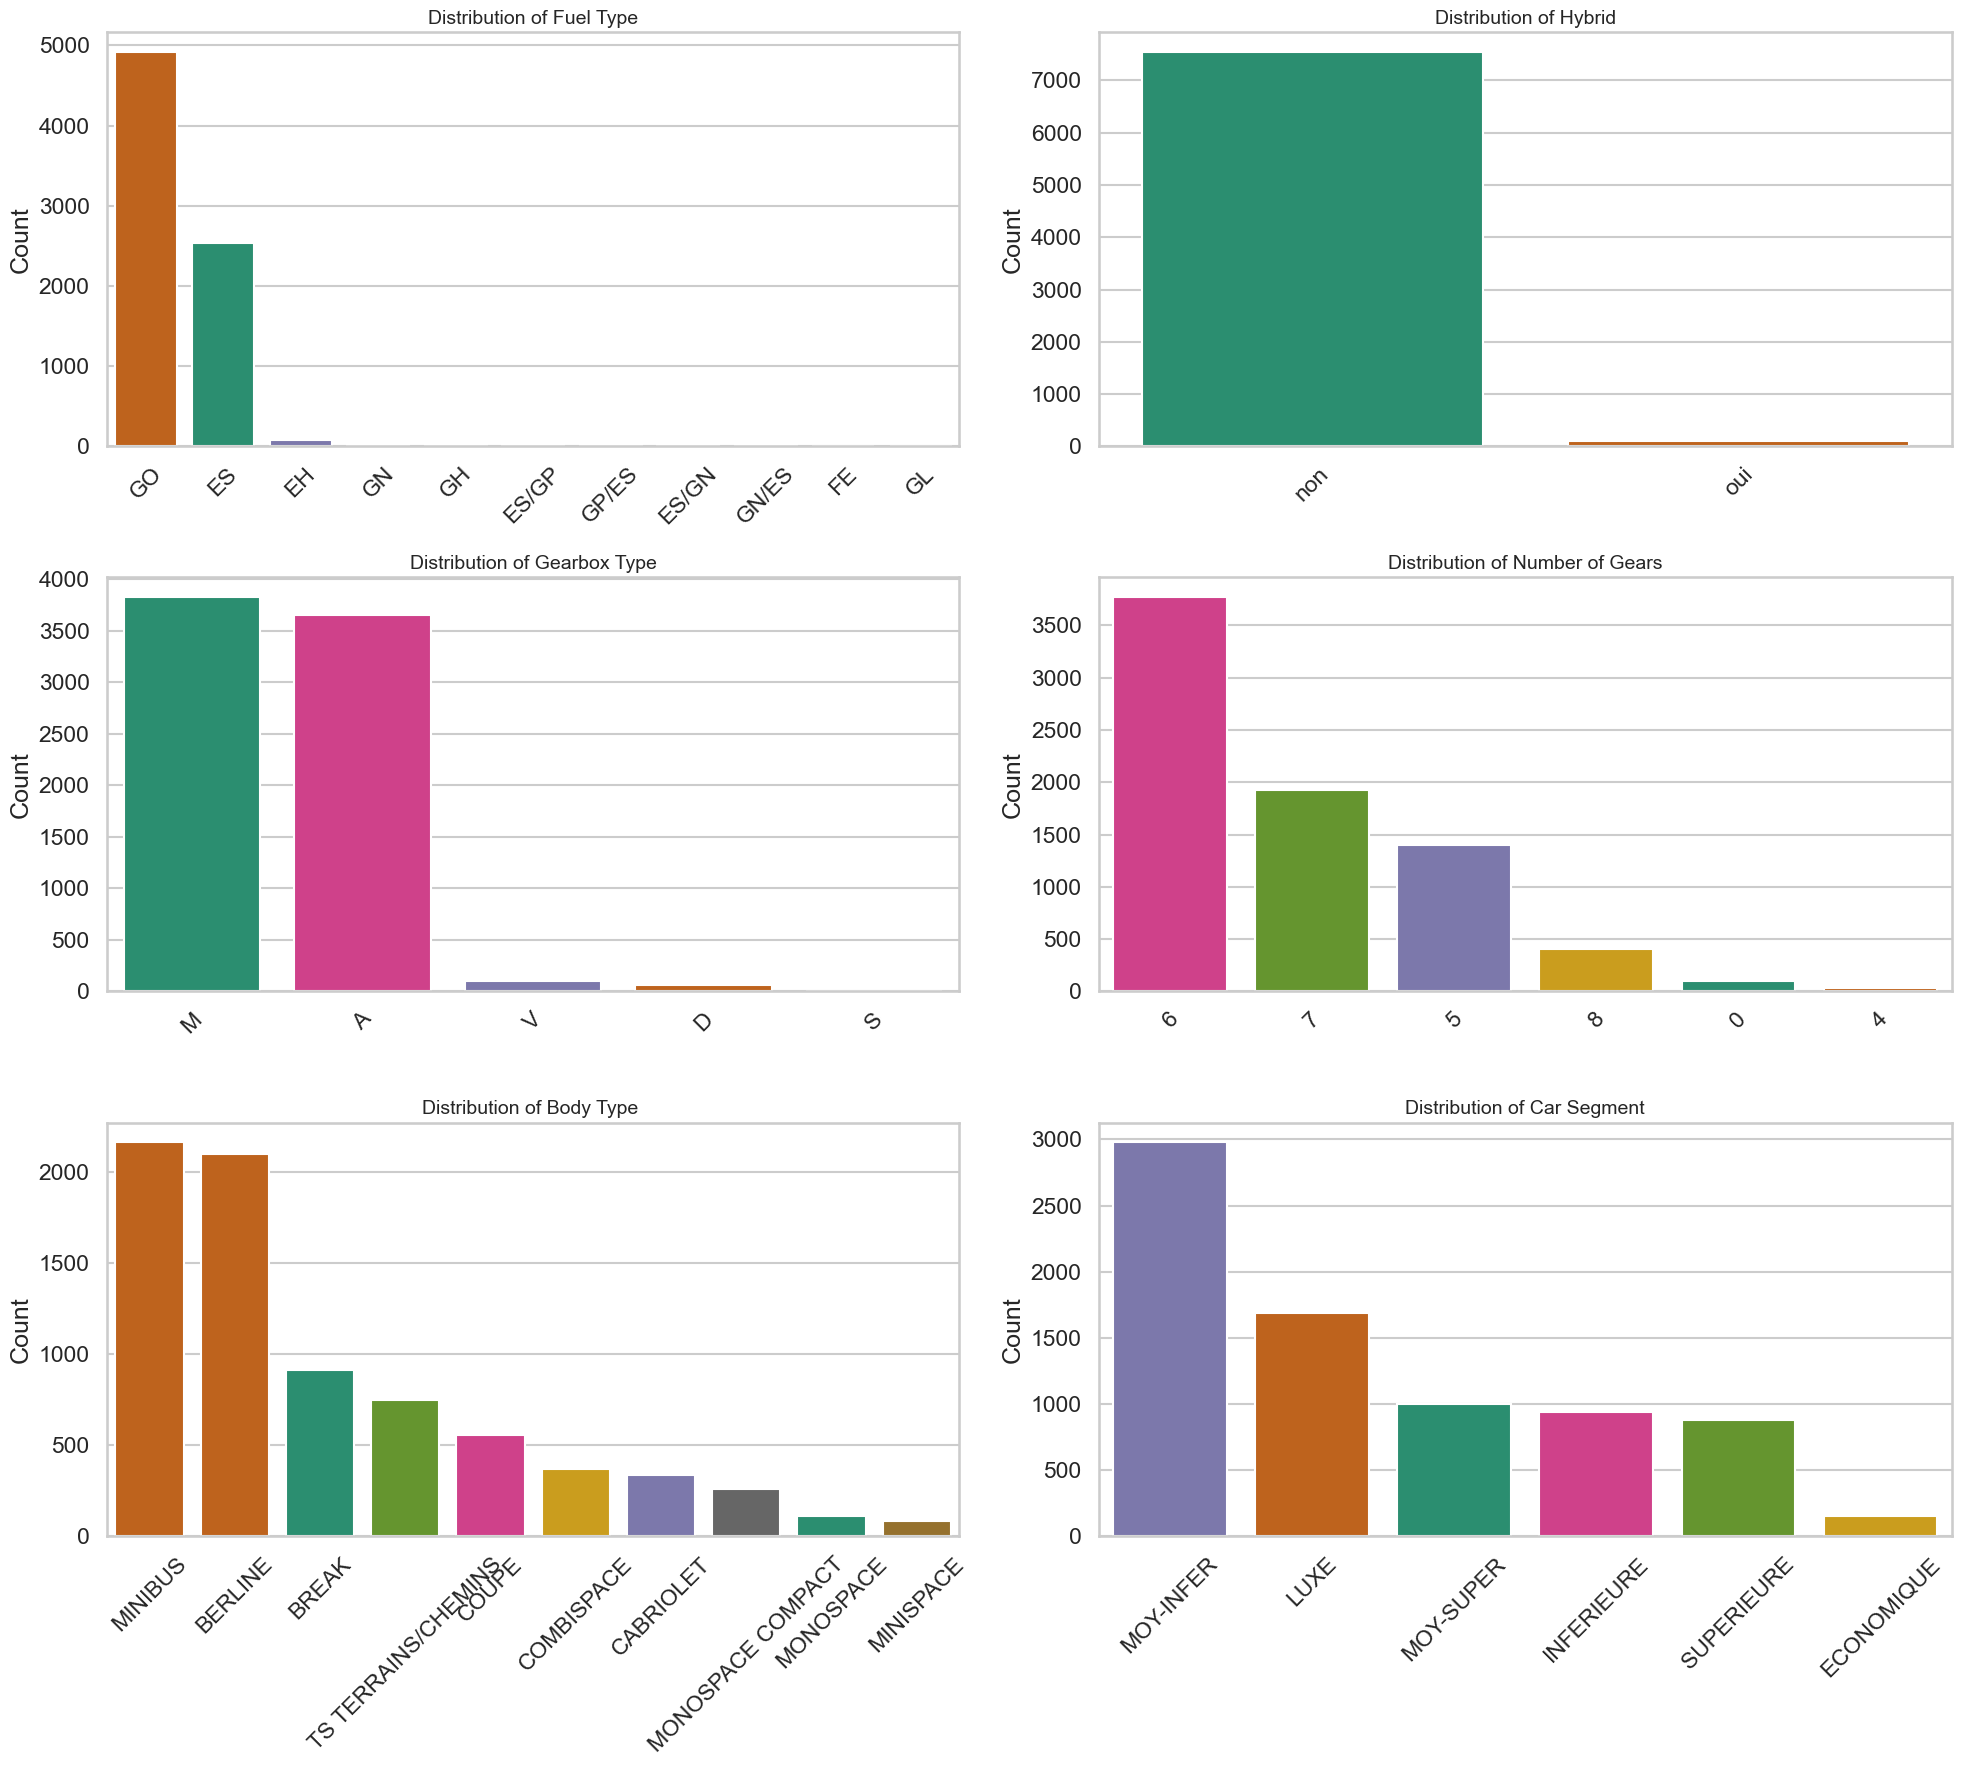

In [187]:
# ----------------------------------------
# COUNT PLOT PLOTS FOR CATEGORICAL FEATURES
# ----------------------------------------

# Features to plot
categorical_features = ['Carburant', 'Hybride', "gearbox_type",'num_gears', 'Carrosserie', 'gamme']
target = 'CO2 (g/km)'  

# Mapping of internal column names to display names in English and for better readability & understanding of data in the plots
feature_name_mapping = {
    'Carburant': 'Fuel Type',
    'Hybride': 'Hybrid',
    'gearbox_type': 'Gearbox Type',
    'num_gears': 'Number of Gears',
    'Carrosserie': 'Body Type ',
    'gamme': 'Car Segment'
}

#Better visualization settings for the count plots
# sns.set_style("whitegrid")
# sns.set_context("talk")

fig, axes = plt.subplots(3, 2, figsize=(20, 18))   # subplot grid with 3 rows & 2 columns for 6 categorical features
axes = axes.flatten() # flatten the 2D array of axes to 1D for easy iteration

for i, feature in enumerate(categorical_features):    # loop through the categorical features and plot countplot for each feature
    sns.countplot(x=feature, data=cars_df, ax=axes[i], palette="Dark2",hue=feature,legend=False,  
                  order=cars_df[feature].value_counts().index)    # order the bars by count , so that the most common categories are displayed first in the plot
    
    axes[i].set_title(f'Distribution of {feature_name_mapping[feature]}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**INFERENCES :  From the above Count Plot** ( notable imbalances across categories)
- Fuel Type : GO ( Diesel) has atleast 45% of the car share. Shows older vehicles untill 2013(based on datset) were Diesel & then Petrol(ES).Electrification is very marignal due to lack of stricter norms back then for electrification. ***Heavily skewed towards concentional fuel types(GO,ES)*** while others are relatively less.
- Hybrid : Nearly all (~95%) are non-hybrid, underscoring limited adoption at that time period. ***BIG IMBALANCE towards NON-HYBRIDS***
- Gearbox Type : Manual( M ) transmissions hold ~50%+ share, again popular for cost/reliability in Europe vs. growing Automatic ( A )
- Number of Gears : Shows the domination of 6-Speed Gearbox in both Manual & Automatic. To some extent / as well.
- Bodytype : Minibus (SUVs) & Berline (Sedans) combined more than 50% share
- Car Segment : Moy infer ( Mid Sized) cars claim top spot , since its ideal for families and in both urban or non urban areas. Keeping parking and space constraint. 

**To check and investigate how these Categorical Imbalances relate to our TARGET ( CO2 emission ) , we plot and analyse BOX & VIOLIN PLOTS**

**BOX PLOT** : To check the relationships between categorical features and CO2 emissions.

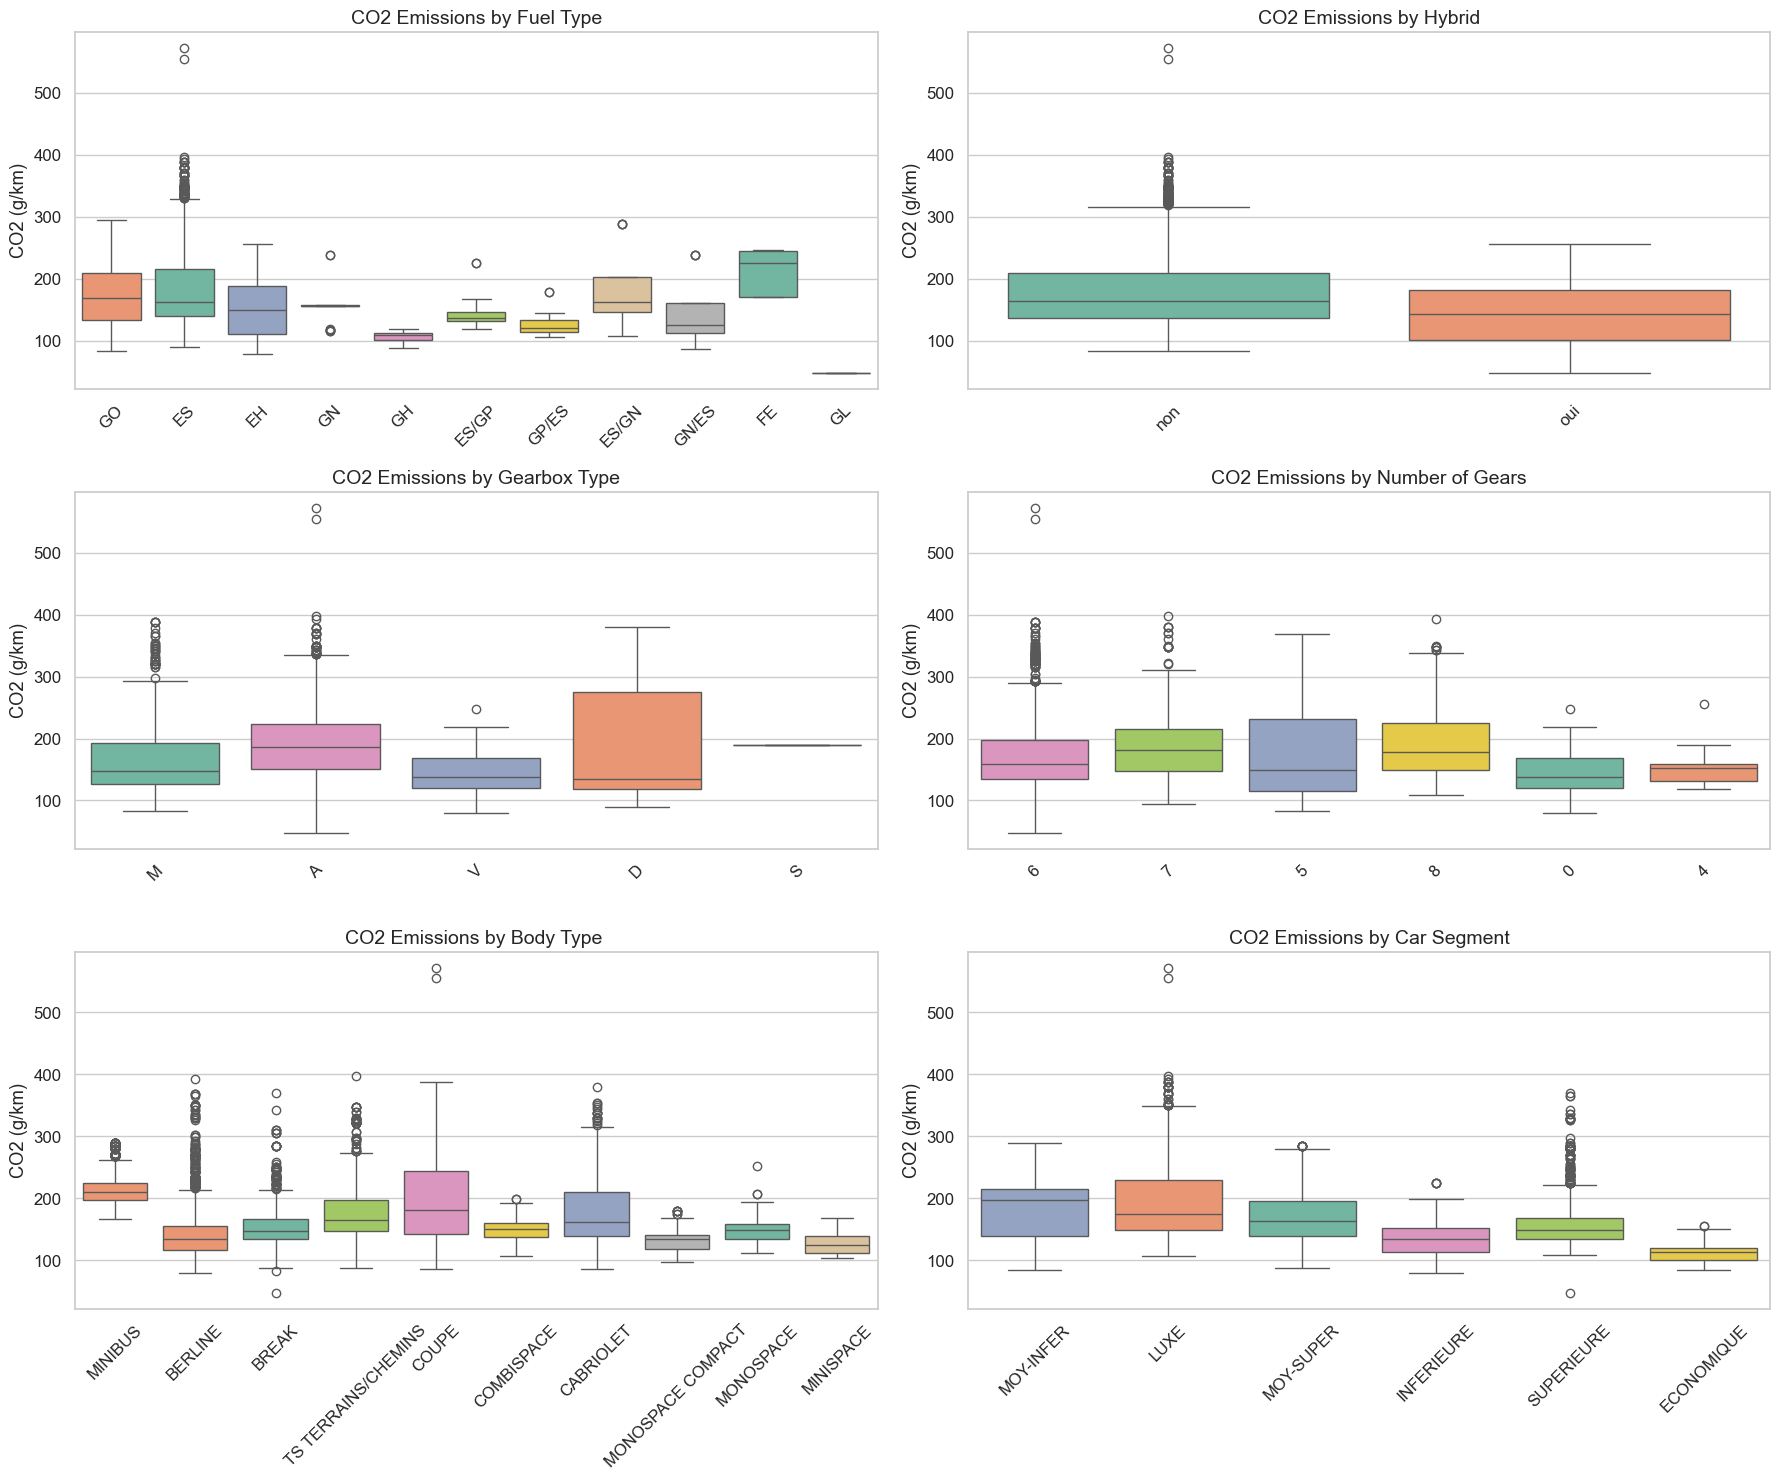

In [188]:
# ----------------------------------------
# BOXPLOT PLOTS FOR CATEGORICAL FEATURES
# ----------------------------------------

# Set style
#for consistency in the visualizations, we will use the same style settings for the boxplots as well.for clean background and better readability of the plots.
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)
    


# Create a figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 15))  # 3 rows x 2 columns . 6 plots 1 per categorical feature
axes = axes.flatten()

# Plot each categorical feature
# Box plot shall show Median (line inside box) ,IQR(box limits) ,spread(whiskers) and outliers (points outside the whiskers)
for i, feature in enumerate(categorical_features):
    sns.boxplot(
        x=feature, y=target, data=cars_df,
        ax=axes[i],
        hue=feature,
        legend=False,
        order=cars_df[feature].value_counts().index,
        palette="Set2"
    )
    axes[i].set_title(f'CO2 Emissions by {feature_name_mapping[feature]}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('CO2 (g/km)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**INFERENCES :  From the above BOX Plot**
- Fuel Type : GO ( Diesel) has the highest median CO2 emissions (~170 g/hm) , with GL (CNG) being the lowest.Extreme outliers exsist in petrol categories(upto 400+ g/km) , indicating  high     perfromance vehicles significantly have high emissions.Low emission fuels have consistently show lower medians.
- Hybrid : Non-hybrids produce comparatively higher emissions (+170 g/km) compared to hybrid vehicles (median ~130 g/km) .Shows an aaprx., 20-25% reduction. Even in hybrids whisers are spread , suggesting variability matters ( may be engine size , weight , or other parameters)
- Gearbox Type : Manual( M ) and Automatic (A) transmissions show similar median emissions in the range from (~160-180 g/km) with high outliers. The variability in other segments suggest that others factors also dominate the emissions.
- Number of Gears : 6-gear transmissions have the lowest median emissions (~150-160 g/km), suggesting optimal balance between performance and efficiency.4-gear and fewer gears also show higher emissions, while 8+ gears don't show any significant advantage or additional improvement, indicating 6 being the optimal choice.
- Bodytype : Coupe and MINIBUS (Vans) have the highest median emissions (~200-220 g/km), while minivans/minispaces are most efficient (~120-130 g/km).
Body type is a strong predictor of emissions - larger, aerodynamically challenging vehicles (SUVs, coupes) produce significantly more CO2 than practical, compact designsMinibus (SUVs).
- Car Segment : Luxury (LUXE) & MOY SUPER & SUPERIEURE have the highest median emissions almost touching ~200 g/km . While , the ECONOMIQUE (economy cars ) segments are most efficient (~120-130 g/km).

**Clear indication and correlation between market positioning of vehciles w.r.t emissions** :- Premium/performance/Luxury vehicles prioritize power over efficiency, creating a 50% emissions gap between segments

**VIOLIN PLOTS** : Showing the combination of Box plots and the feature distribution

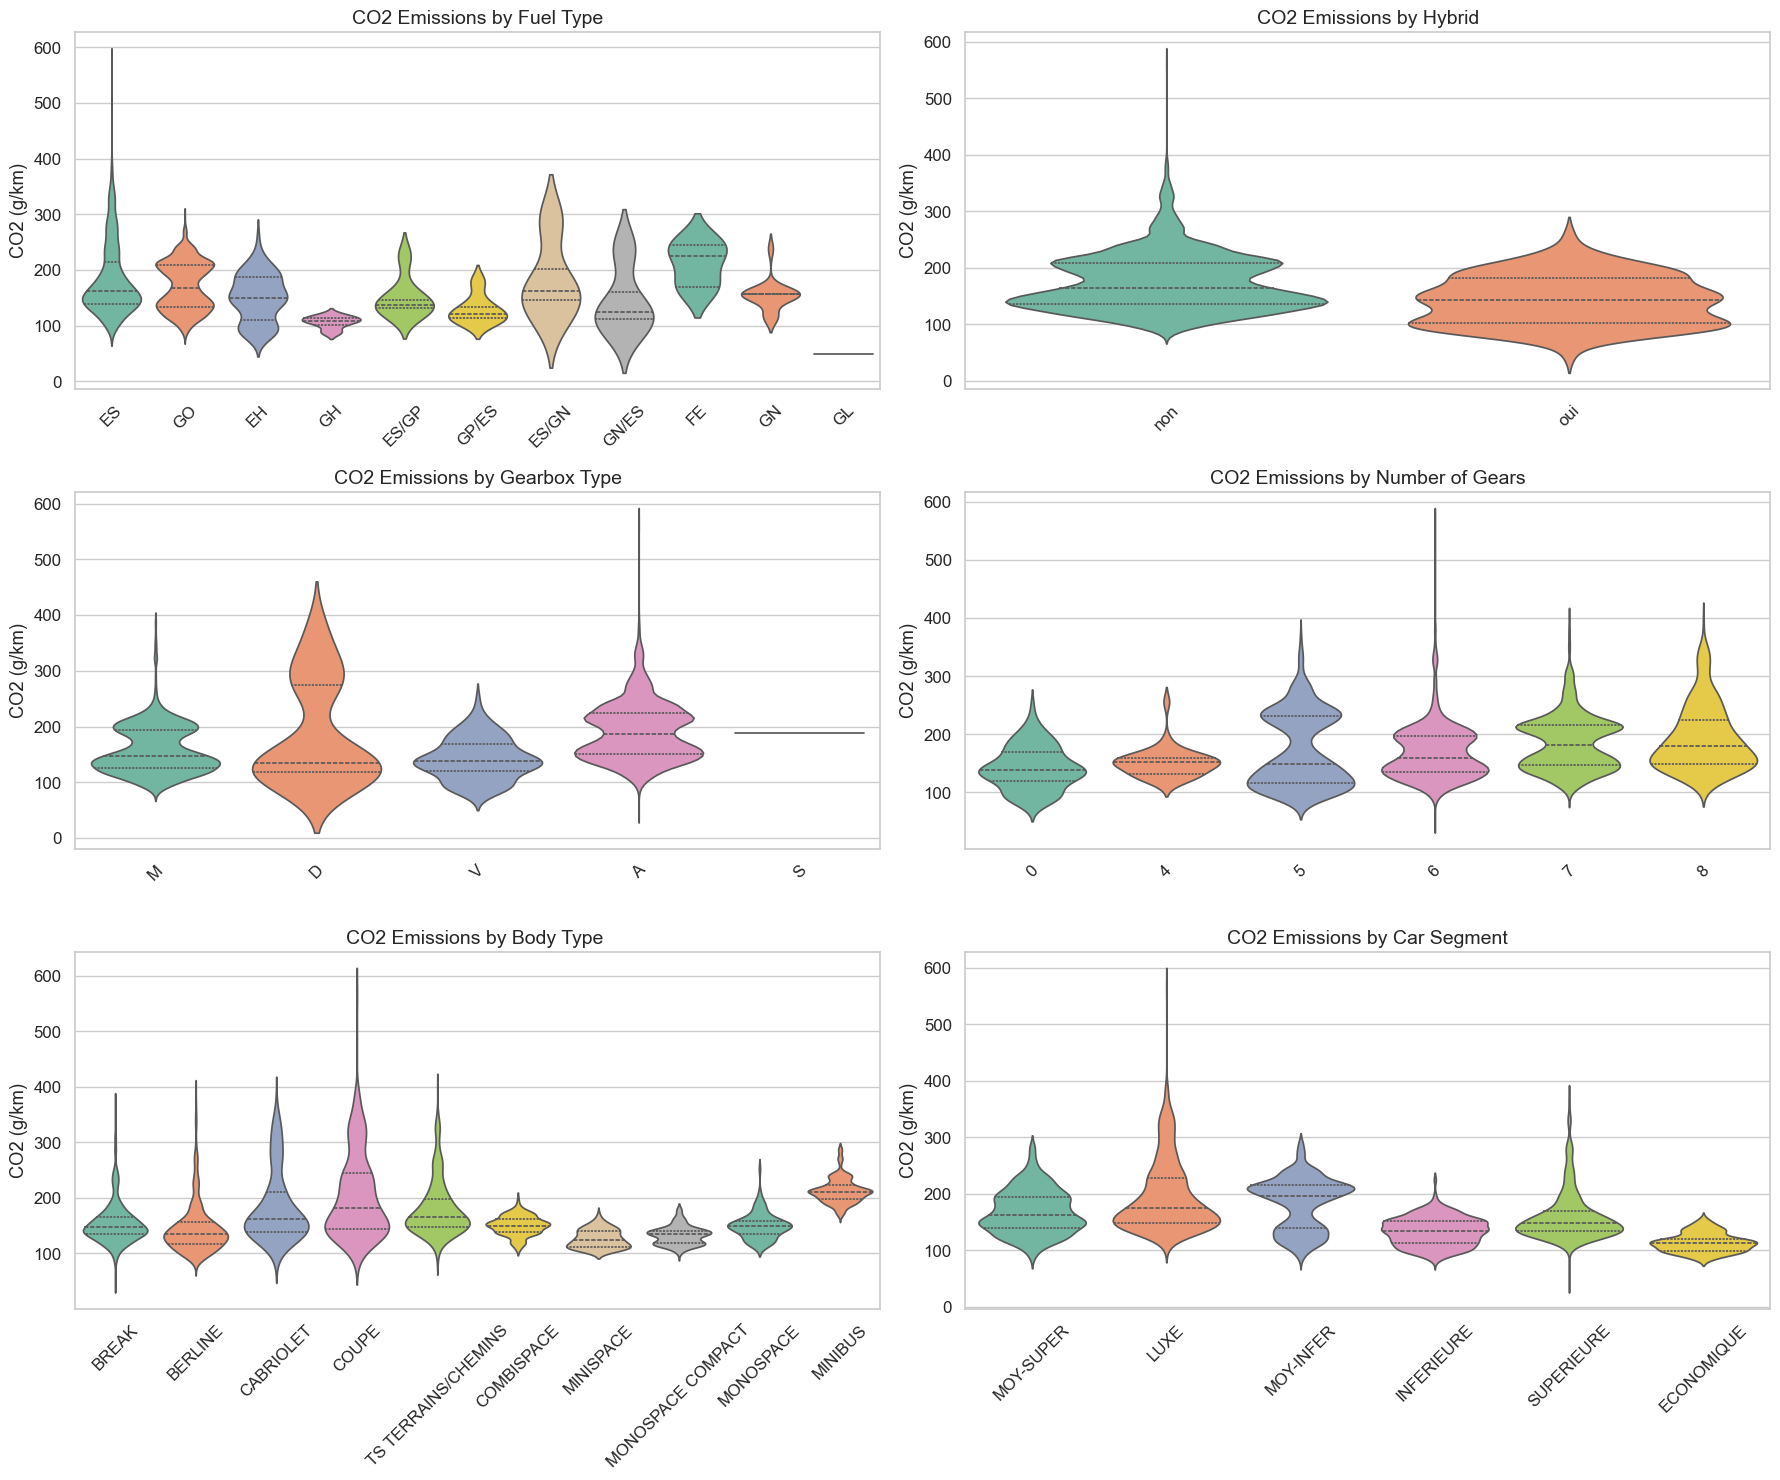

In [141]:
# ----------------------------------------
# VIOLIN PLOTS FOR CATEGORICAL FEATURES    
# Box plot and distribution combined
# ----------------------------------------

# Set style
#for consistency in the visualizations, we will use the same style settings for the boxplots as well.for clean background and better readability of the plots.
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)
    


# Create a figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 15))  # 3 rows x 2 columns . 6 plots 1 per categorical feature
axes = axes.flatten()

# Plot each categorical feature
# Violin plot shall show Median (line inside box) ,IQR(box limits) ,spread(whiskers) and outliers (points outside the whiskers)
for i, feature in enumerate(categorical_features):
    sns.violinplot(
        x=feature, y=target, data=cars_df,
        ax=axes[i],
        hue=feature,
        legend=False,
        #order=cars_df[feature].value_counts().index,
        palette="Set2",
        inner="quartile"
    )
    axes[i].set_title(f'CO2 Emissions by {feature_name_mapping[feature]}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('CO2 (g/km)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**INFERENCES from the above VIOLIN PLOT**:
- Fuel Type: 
  - GN is the Narrowest/tightest (~160 g/km median ), almost NO tails , with lowest variance. Most predictable.
  - ES  Widest bimodal (peaks ~150/250 g/km, tail to 500+ g/km)—high variability. Also overlaps with other categories , hence heterogenous grouping. ( ES / GP , ES / GN etc ).Others (EH, GH, etc.). Broad, overlapping fuel-spread alone predicts poorly. Shows there are sub types.

- Hybrid Type: 
  - Hybrid (oui) is  Symmetric, shifted low (~150 g/km median, tight to 300 g/km). Hybrids have straightaway cut variance by ~40-50% visually.
  - Non-hybrid: Bimodal (peaks ~150/210 g/km), wide to 600 g/km outliers.

- Gearbox Type
  - M (Manual): Tight ~130-150 g/km.Mostly found in economy & mid range cars.
  - A (Auto): Broadest ~150-300 g/km core + tails.Present in diverse range of vehicles ( budget autos,luxury sedans,Minivans,SUVs etc )
  - V/D/S: Very low data for any logical prediction. Also oberved to have higher medians , since they are present in permiums/hybrid/EVs etc. 

Insight: DIVERSE correlations with migh & low Emission Vehicles.

- Number of Gears
  - 6 gears: Tightest ~140-150 g/km—"Best config to have -optimally placed"
  - 4 gears: Higher median (~160 g/km), widespread , but no advantage w.r.t emissions.
  - 7/8 gears: Narrow but shifted higheest median (~150-200 g/km)., but no advantage w.r.t emissions.

Insight: 6-gear optimal; Outliers / extremes for niche vehicles.

- Body Type
  - CABRIOLET: CABRIOLET shows a wide, bimodal distribution from about 50 to 410 g/km, mixing low‑ and mid/high‑emission vehicles.
  - COUPE: High median (~200 g/km).COUPE is tightly clustered at high emissions with a tail up to ~610 g/km.Consistenly on high emission.

Insight: Body type proxies engine size, weight, and usage & other factors, which in turn shapes the CO₂ emissions. Whereas Family oreinted vehicles such minivan,compact vehicles,break(estates type) sit on a very tight bank and low CO2. Since its designed for effiecncy rather than power.

- Car Segment
  - ECONOMIQUE/INFERIEURE: Lowest/tightest ~110-140 g/km.Stable band.

  - LUXE: Widest 100-600 g/km.
  - MOV/SUPER: ~200 g/km median.

Insight: Segment strongest separator (economy vs. luxury non-overlap).



**Combined Inference from BOX plots and VIOLIN plots** : 
  - Vehicles are dominated by category groups , features such as fulel type , hybrid status , and car segment also exhibits consistent and strongest associations with Co2 emissions.
  - Gearboxtype,Number of gears,body type contribute on variability and also via presence of OUTLIERS.